In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Зашумить изображение при помощи шума гаусса, постоянного шума.

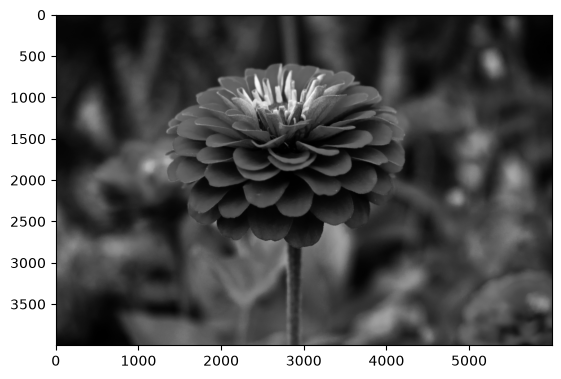

In [3]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

plt.imshow(image_gray, cmap="gray")

In [10]:
# гауссов шум
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  26, 217, ...,   0,  74,   0],
       [  0,   0,   0, ...,  19,  67,   0],
       [  0,   0,  34, ...,   0,   0,  81],
       ...,
       [  0,   0,  94, ..., 133,  84,   0],
       [  0,   0, 174, ...,   0, 122, 228],
       [  0,   0,   0, ...,   1,   0,  96]],
      shape=(4000, 6000), dtype=uint8)

Text(0.5, 1.0, 'Изображение с шумом')

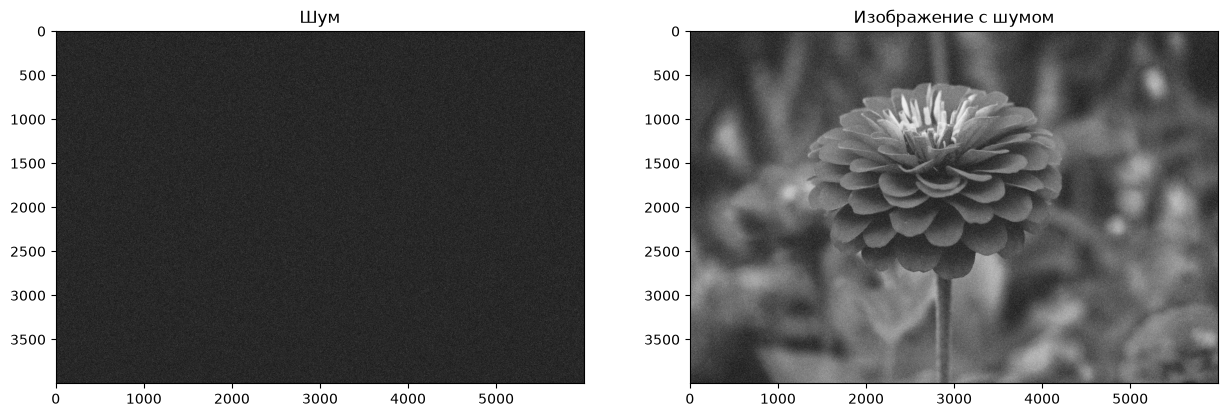

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(noise_gauss, cmap="gray")
axes[0].set_title('Шум')

image_noise_gauss = cv2.add(image_gray,noise_gauss)
axes[1].imshow(image_noise_gauss, cmap="gray")
axes[1].set_title('Изображение с шумом')

In [5]:
# постоянный шум
a = 0
b = 100
noise = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise, a, b)
image_uniform = cv2.add(image_gray, noise)

Text(0.5, 1.0, 'Изображение с шумом')

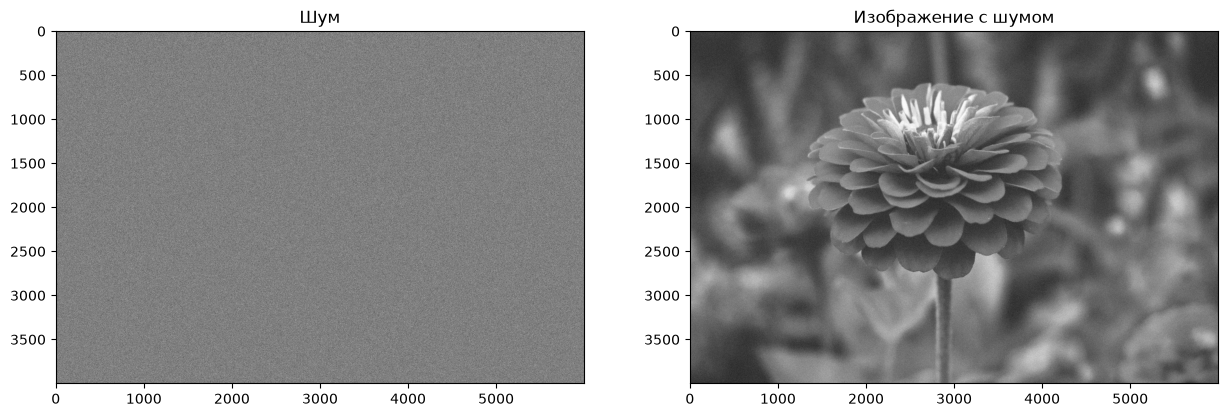

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(noise, cmap="gray")
axes[0].set_title('Шум')

axes[1].imshow(image_uniform, cmap="gray")
axes[1].set_title('Изображение с шумом')

# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [8]:
from skimage.metrics import structural_similarity, mean_squared_error

In [16]:
# для гаусса
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print('Gauss:', mse_gauss, ssim_gauss)

# для постоянного шума
mse_uniform = mean_squared_error(image_gray, image_uniform)
(ssim_uniform, diff) = structural_similarity(image_gray, image_uniform, full=True)
print('Uniform:', mse_sp, ssim_sp)

Gauss: 4499.768752625 0.025895957984348166
Salt Pepper: 3276.3367733333334 0.07371796784287671


In [12]:
# медианный фильтр
# для гаусса
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

print('Gauss:', mse_gauss_median, ssim_gauss_median)

# для постоянного шума
image_uniform_median = cv2.medianBlur(image_uniform, 3)

mse_uniform_median = mean_squared_error(image_gray, image_uniform_median)
(ssim_uniform_median, diff) = structural_similarity(image_gray, image_uniform_median, full=True)
print('Uniform:', mse_uniform_median, ssim_uniform_median)

Gauss: 843.6844224166666 0.15372631055398972
Salt Pepper: 2680.91294025 0.19493149282853928


In [13]:
# фильтр гаусса
# для гаусса
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss, full=True)

print('Gauss:', mse_gauss_gauss, ssim_gauss_gauss)

# для постоянного шума
image_uniform_gauss = cv2.GaussianBlur(image_uniform,(5,5),0)

mse_uniform_gauss = mean_squared_error(image_gray, image_uniform_gauss)
(ssim_uniform_gauss, _) = structural_similarity(image_gray, image_uniform_gauss, full=True)

print('Uniform:', mse_uniform_gauss, ssim_uniform_gauss)

Gauss: 1729.6954640833333 0.23055148518475096
Salt Pepper: 2515.403298875 0.4060402795331853


In [18]:
# билатериальный фильтр
# для гаусса
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat)
(ssim_gauss_bilat, _) = structural_similarity(image_gray, image_gauss_bilat, full=True)

print('Gauss:', mse_gauss_bilat, ssim_gauss_bilat)

# для постоянного шума
image_uniform_bilat = cv2.bilateralFilter(image_uniform,9,75,75)

mse_uniform_bilat = mean_squared_error(image_gray, image_uniform_bilat)
(ssim_uniform_bilat, _) = structural_similarity(image_gray, image_uniform_bilat, full=True)

print('Uniform:', mse_uniform_bilat, ssim_uniform_bilat)

Gauss: 1787.1500062083333 0.10448106602215468
Salt Pepper: 2490.024713875 0.4832019410214016


In [14]:
# фильтр нелокальных средних
# для гаусса
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)

mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm)
(ssim_gauss_nlm, _) = structural_similarity(image_gray, image_gauss_nlm, full=True)

print('Gauss:', mse_gauss_nlm, ssim_gauss_nlm)

# для постоянного шума
image_uniform_nlm = cv2.fastNlMeansDenoising(image_uniform, h=20)

mse_uniform_nlm = mean_squared_error(image_gray, image_uniform_nlm)
(ssim_uniform_nlm, _) = structural_similarity(image_gray, image_uniform_nlm, full=True)
    
print('Uniform:', mse_uniform_nlm, ssim_uniform_nlm)

Gauss: 4487.553010125 0.028928244276566675
Salt Pepper: 2489.4677078333334 0.46352477341072007


# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [19]:
table = np.array([
    [mse_gauss, ssim_gauss, mse_uniform, ssim_uniform],
    [mse_gauss_median, ssim_gauss_median, mse_uniform_median, ssim_uniform_median],
    [mse_gauss_gauss, ssim_gauss_gauss, mse_uniform_gauss, ssim_uniform_gauss],
    [mse_gauss_bilat, ssim_gauss_bilat, mse_uniform_bilat, ssim_uniform_bilat],
    [mse_gauss_nlm, ssim_gauss_nlm, mse_uniform_nlm, ssim_uniform_nlm],
])
labels = ['Noisy', 'Median', 'Gaussian', 'Bilateral', 'NLM']

for i, name in enumerate(labels):
    mse_g, ssim_g, mse_u, ssim_u = table[i]
    print(f'{name:<10}'
          f'gauss: MSE={mse_g:>8.2f}, SSIM={ssim_g:.2f}  '
          f'uniform: MSE={mse_u:>7.2f}, SSIM={ssim_u:.2f}')

Noisy     gauss: MSE= 4499.77, SSIM=0.03  sp: MSE=3276.34, SSIM=0.07
Median    gauss: MSE=  843.68, SSIM=0.15  sp: MSE=2680.91, SSIM=0.19
Gaussian  gauss: MSE= 1729.70, SSIM=0.23  sp: MSE=2515.40, SSIM=0.41
Bilateral gauss: MSE= 1787.15, SSIM=0.10  sp: MSE=2490.02, SSIM=0.48
NLM       gauss: MSE= 4487.55, SSIM=0.03  sp: MSE=2489.47, SSIM=0.46


In [21]:
# лучший результат фильтрации для гаусса

# индекс строки с минимальным gauss_MSE
idx_best_gauss_mse = np.argmin(table[:, 0])
# индекс строки с максимальным gauss_SSIM
idx_best_gauss_ssim = np.argmax(table[:, 1])

print('Лучший по MSE для гаусса:')
print(f'{labels[idx_best_gauss_mse]}: '
      f'gauss_MSE={table[idx_best_gauss_mse, 0]:.2f}, '
      f'gauss_SSIM={table[idx_best_gauss_mse, 1]:.4f}')

print()
print('Лучший по SSIM для гаусса:')
print(f'{labels[idx_best_gauss_ssim]}: '
      f'gauss_MSE={table[idx_best_gauss_ssim, 0]:.2f}, '
      f'gauss_SSIM={table[idx_best_gauss_ssim, 1]:.4f}')

Лучший по MSE для гаусса:
Median: gauss_MSE=843.68, gauss_SSIM=0.1537

Лучший по SSIM для гаусса:
Gaussian: gauss_MSE=1729.70, gauss_SSIM=0.2306


In [22]:
# лучший результат фильтрации для постоянного шума

# индекс строки с минимальным uniform_MSE
idx_best_uniform_mse = np.argmin(table[:, 2])
# индекс строки с максимальным uniform_SSIM
idx_best_uniform_ssim = np.argmax(table[:, 3])

print('Лучший по MSE для соль-перца:')
print(f'{labels[idx_best_uniform_mse]}: '
      f'uniform_MSE={table[idx_best_uniform_mse, 2]:.2f}, '
      f'uniform_SSIM={table[idx_best_uniform_mse, 3]:.4f}')

print()
print('Лучший по SSIM для соль-перца:')
print(f'{labels[idx_best_uniform_ssim]}: '
      f'uniform_MSE={table[idx_best_uniform_ssim, 2]:.2f}, '
      f'uniform_SSIM={table[idx_best_uniform_ssim, 3]:.4f}')

Лучший по MSE для соль-перца:
NLM: sp_MSE=2489.47, sp_SSIM=0.4635

Лучший по SSIM для соль-перца:
Bilateral: sp_MSE=2490.02, sp_SSIM=0.4832
